# 🎬 Netflix Movies & TV Shows — Exploratory Data Analysis

**Dataset:** Netflix Movies and TV Shows (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

Netflix has grown from a DVD rental service to one of the biggest content libraries in the world. In this notebook, I explore the dataset to understand what kind of content Netflix offers, where it comes from, how it's grown over the years, and what patterns emerge across genres, ratings, and durations.

Let's dig in.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports & Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# consistent plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded. Let's go.")

All libraries loaded. Let's go.


---
## Step 1 — Load & Inspect the Data

First things first — load the CSV and get a feel for what we're working with.

In [42]:
df = pd.read_csv('netflix_titles.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

Shape: (8807, 12)
Rows: 8807 | Columns: 12


In [43]:
# first look at the data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [44]:
# column names and data types
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [45]:
# how many missing values per column?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage (%)
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [46]:
# check for duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# quick summary of what we have
print("\nContent type split:")
print(df['type'].value_counts())

Duplicate rows: 0

Content type split:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


**Summary of what we found:**
- The dataset has ~8,800 titles with 12 columns.
- `director`, `cast`, and `country` have the most missing values — makes sense, not every title has that info publicly listed.
- `date_added` and `rating` are also missing for a handful of rows.
- No duplicate rows.
- Movies outnumber TV Shows roughly 2:1.

---
## Step 2 — Clean the Data

Let's handle the missing values and fix column formats so everything is ready for analysis.

In [47]:
# fill missing text fields with 'Unknown' — dropping them would lose too much data
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# drop rows where rating or date_added is missing — very few and not worth guessing
df.dropna(subset=['rating', 'date_added'], inplace=True)

print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 8793


In [48]:
# fix date_added — convert to datetime and extract year + month
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Date columns extracted successfully.")
df[['date_added', 'year_added', 'month_added']].head()

Date columns extracted successfully.


,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [49]:
# for movies — extract numeric duration in minutes
movies = df[df['type'] == 'Movie'].copy()
movies = movies[movies['duration'].notna()]  # drop rows where duration is missing
movies['duration_mins'] = movies['duration'].str.replace(' min', '').str.strip().astype(int)

# for TV shows — extract number of seasons
shows = df[df['type'] == 'TV Show'].copy()
shows = shows[shows['duration'].notna()]  # same here
shows['num_seasons'] = shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').str.strip().astype(int)

print(f"Movies: {len(movies)} | TV Shows: {len(shows)}")

Movies: 6126 | TV Shows: 2664


In [50]:
# take only the first country listed (some titles have multiple, comma-separated)
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown')

# same for genres (listed_in column)
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

print("Country and genre columns cleaned.")
print("\nTop 5 primary genres:")
print(df['primary_genre'].value_counts().head())

Country and genre columns cleaned.

Top 5 primary genres:
primary_genre
Dramas                    1599
Comedies                  1210
Action & Adventure         859
Documentaries              829
International TV Shows     773
Name: count, dtype: int64


In [51]:
# final check — no remaining nulls in key columns
print("Remaining nulls in key columns:")
key_cols = ['type', 'title', 'country', 'rating', 'year_added', 'primary_genre']
print(df[key_cols].isnull().sum())

Remaining nulls in key columns:
type             0
title            0
country          0
rating           0
year_added       0
primary_genre    0
dtype: int64


---
## Step 3 — Exploratory Data Analysis

Now for the interesting part. I'll answer 5 questions about this dataset.

### Q1. How is content distributed between Movies and TV Shows?

In [52]:
type_counts = df['type'].value_counts()
print(type_counts)
print(f"\nMovies are {(type_counts['Movie']/len(df)*100):.1f}% of total content.")

type
Movie      6129
TV Show    2664
Name: count, dtype: int64

Movies are 69.7% of total content.


### Q2. Which countries produce the most Netflix content?

In [53]:
top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)
print(top_countries)

primary_country
United States     3205
India             1008
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Australia          115
Name: count, dtype: int64


### Q3. How has Netflix content grown year over year?

In [54]:
yearly_content = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(yearly_content)

type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      175
2017          837      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


### Q4. What are the most common content ratings on Netflix?

In [55]:
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


### Q5. What is the distribution of movie durations? Are most Netflix movies short or long?

In [56]:
print(movies['duration_mins'].describe())
print(f"\nMost movies fall between {movies['duration_mins'].quantile(0.25):.0f} and {movies['duration_mins'].quantile(0.75):.0f} minutes.")

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_mins, dtype: float64

Most movies fall between 87 and 114 minutes.


---
## Step 4 — Visualizations (6 Charts)

Let's put the numbers into pictures.

### Chart 1 — Pie Chart: Movies vs TV Shows

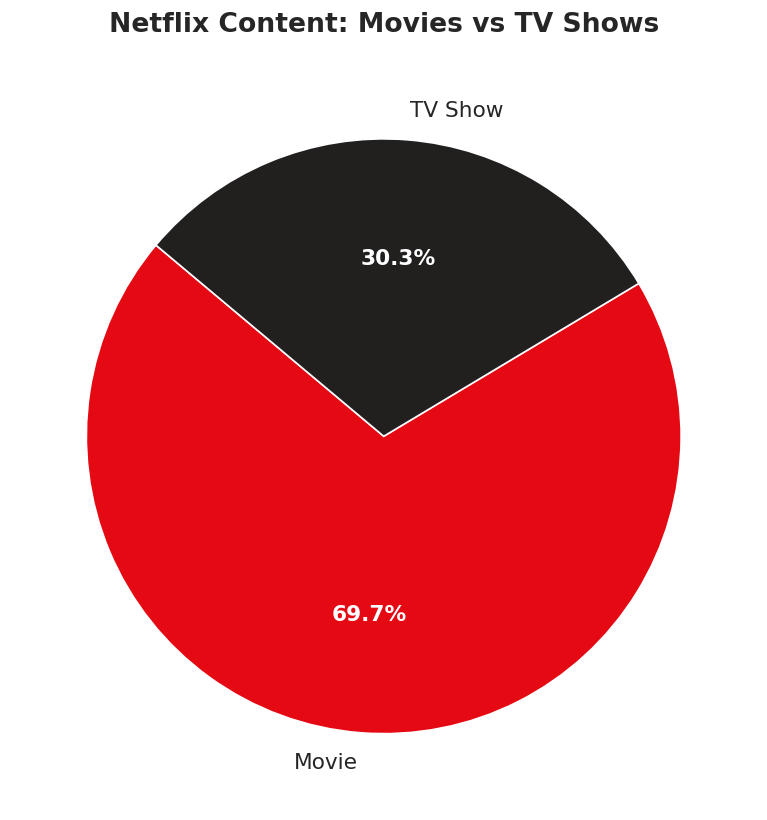

In [57]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#E50914', '#221F1F']
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Netflix Content: Movies vs TV Shows', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_pie_content_type.png', bbox_inches='tight')
plt.show()

### Chart 2 — Bar Chart: Top 10 Content-Producing Countries

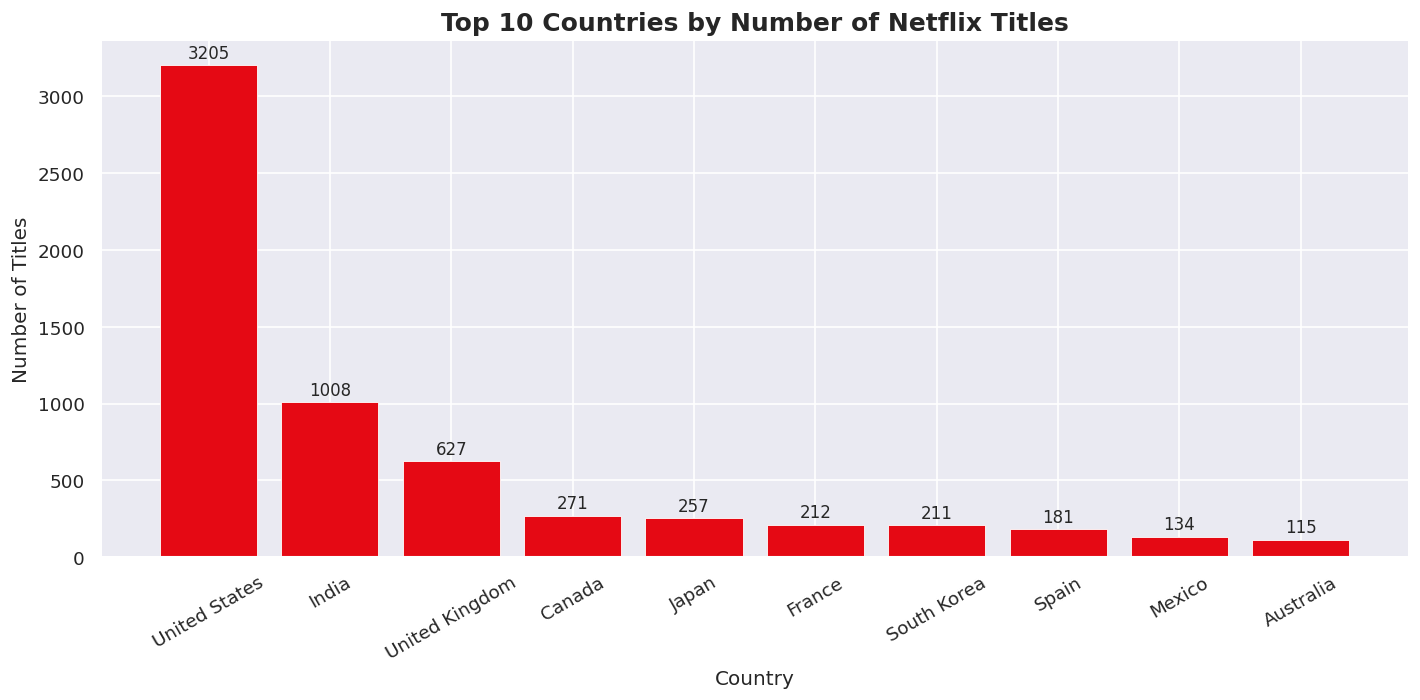

In [58]:
top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_countries.index, top_countries.values, color='#E50914', edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Top 10 Countries by Number of Netflix Titles', fontsize=15, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('chart2_bar_top_countries.png', bbox_inches='tight')
plt.show()

### Chart 3 — Line Chart: Netflix Content Growth Over the Years

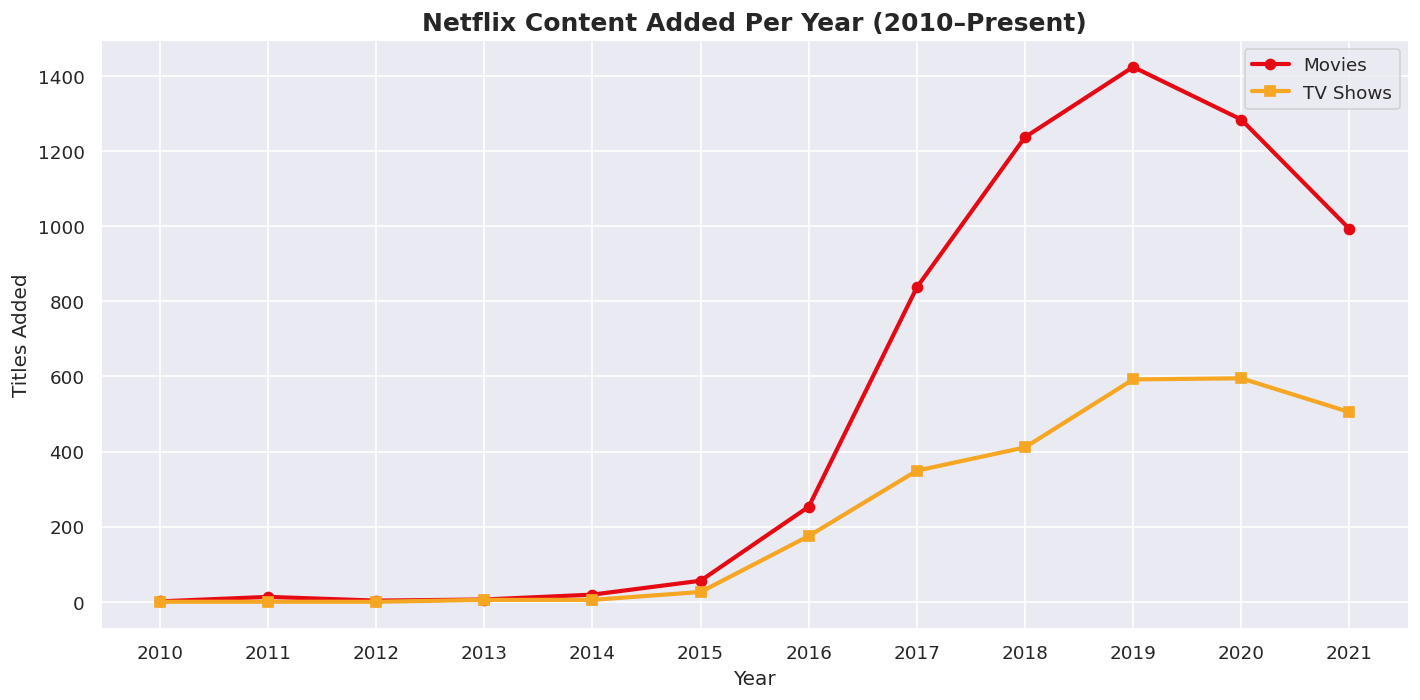

In [59]:
yearly_content = df[df['year_added'] >= 2010].groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_content.index, yearly_content['Movie'], marker='o', linewidth=2.5,
        color='#E50914', label='Movies')
ax.plot(yearly_content.index, yearly_content['TV Show'], marker='s', linewidth=2.5,
        color='#f5a623', label='TV Shows')

ax.set_title('Netflix Content Added Per Year (2010–Present)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Titles Added', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('chart3_line_content_growth.png', bbox_inches='tight')
plt.show()

### Chart 4 — Histogram: Distribution of Movie Durations

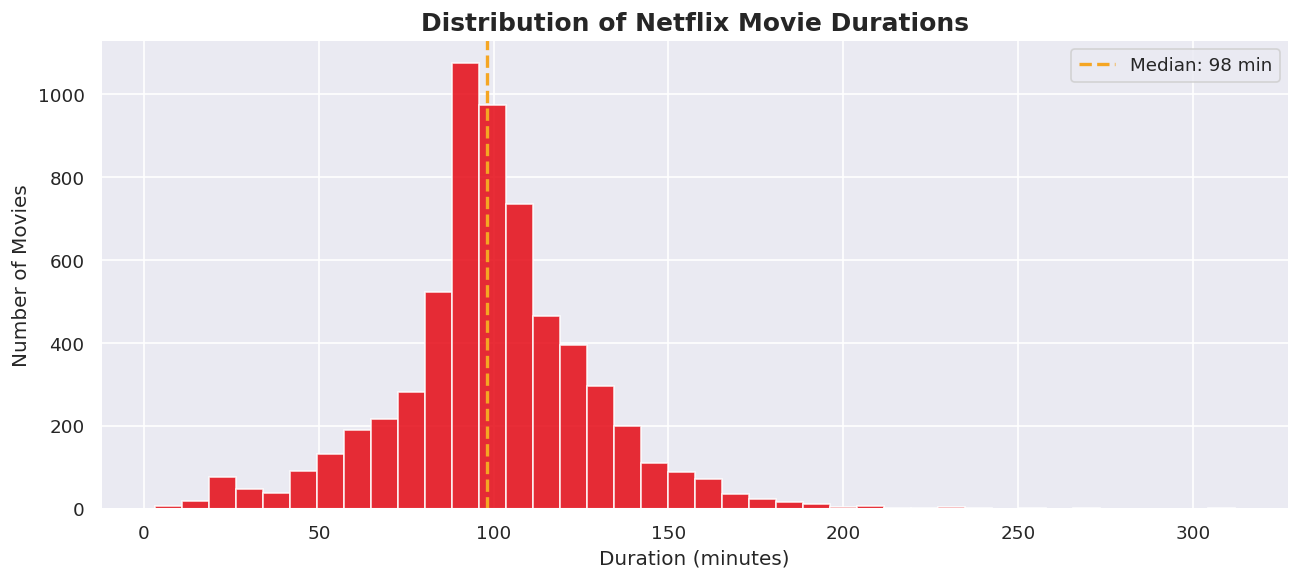

In [60]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(movies['duration_mins'], bins=40, color='#E50914', edgecolor='white', alpha=0.85)
ax.axvline(movies['duration_mins'].median(), color='#f5a623', linewidth=2,
           linestyle='--', label=f"Median: {movies['duration_mins'].median():.0f} min")

ax.set_title('Distribution of Netflix Movie Durations', fontsize=15, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart4_histogram_movie_duration.png', bbox_inches='tight')
plt.show()

### Chart 5 — Bar Chart: Content Ratings Distribution

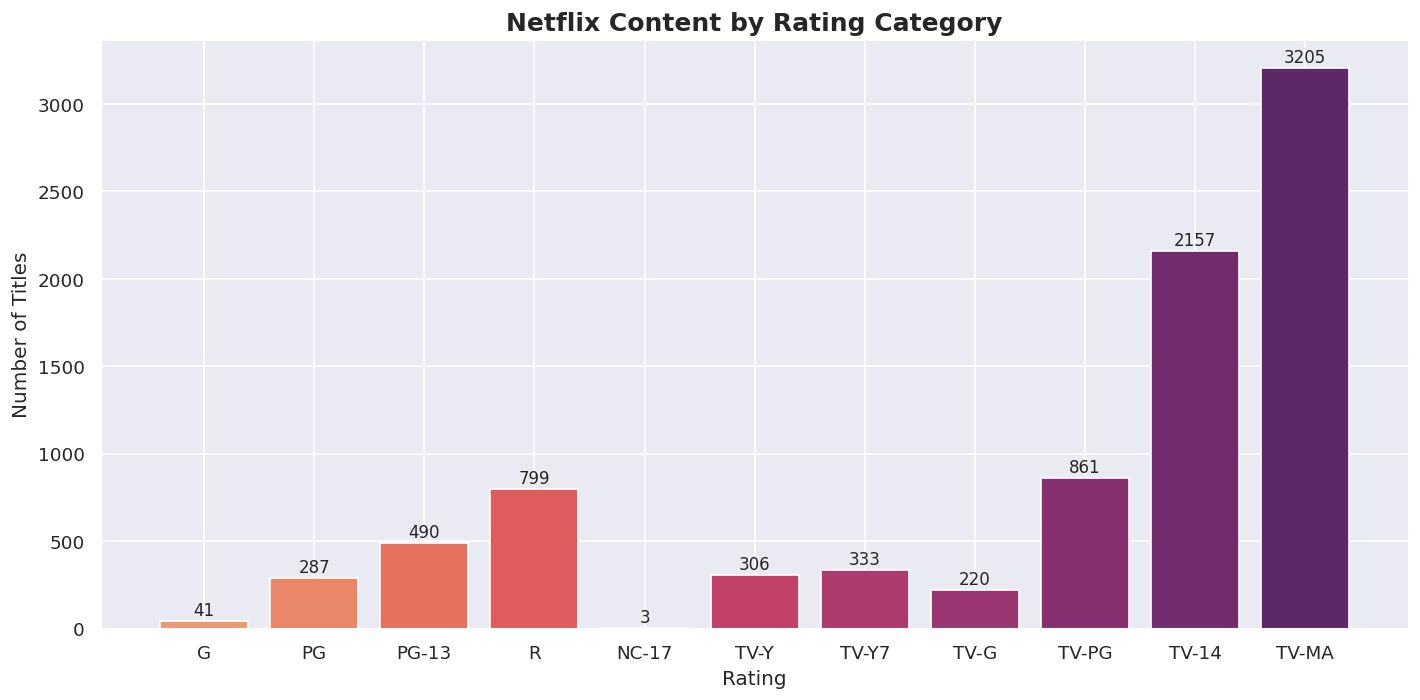

In [61]:
# keep only standard ratings
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'TV-Y', 'TV-Y7', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA']
rating_df = df[df['rating'].isin(valid_ratings)]['rating'].value_counts().reindex(valid_ratings).dropna()

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette("flare", len(rating_df))
bars = ax.bar(rating_df.index, rating_df.values, color=palette, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Netflix Content by Rating Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_bar_ratings.png', bbox_inches='tight')
plt.show()

### Chart 6 — Heatmap: Content Added by Month and Year

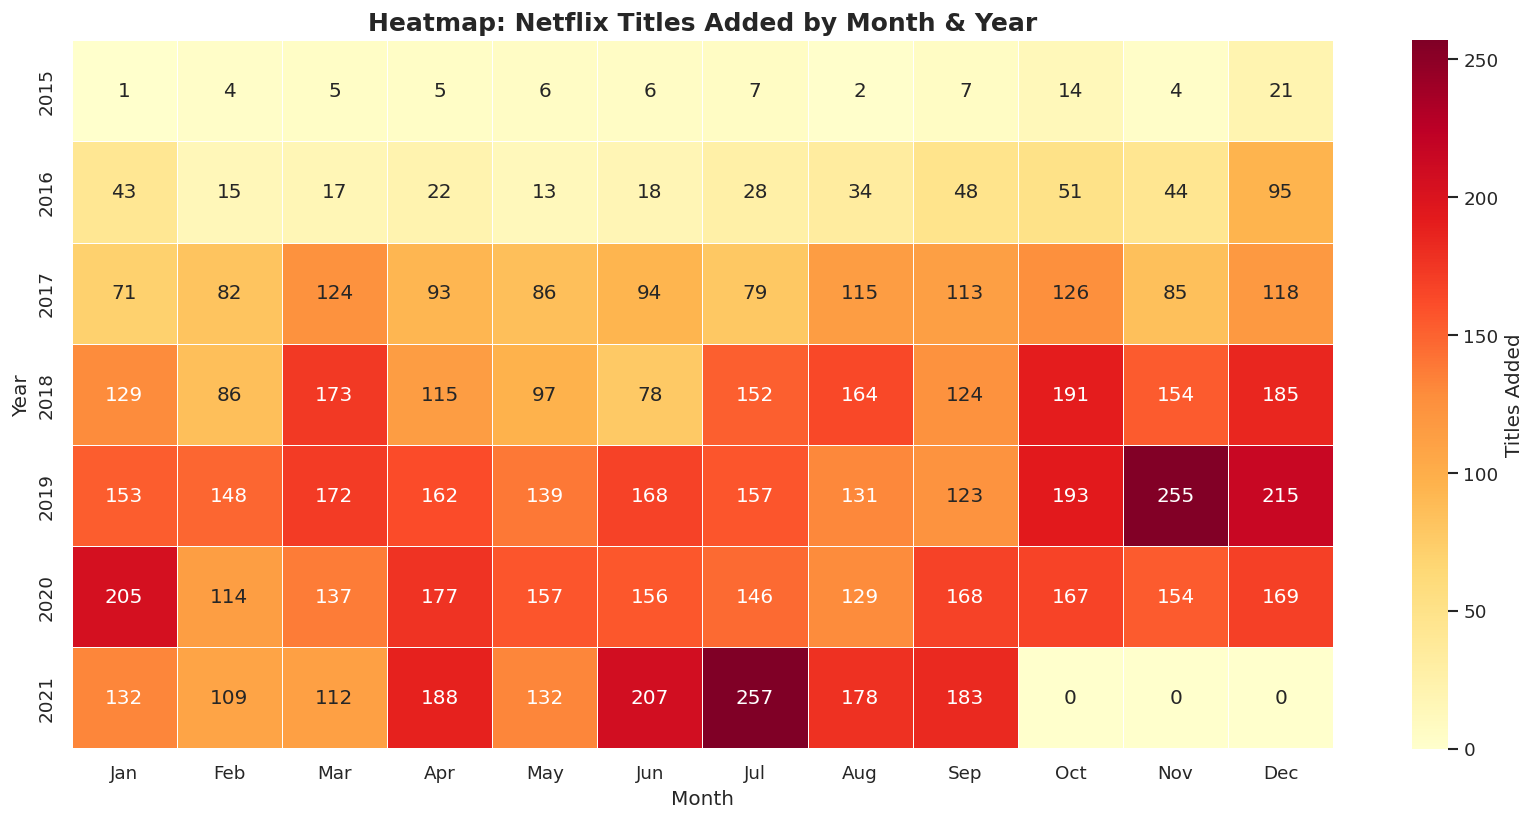

In [62]:
month_year = df[df['year_added'] >= 2015].groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
month_year.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(month_year, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Titles Added'})

ax.set_title('Heatmap: Netflix Titles Added by Month & Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_heatmap_monthly.png', bbox_inches='tight')
plt.show()

### Chart 7 — Scatter Plot: Movie Duration vs Release Year

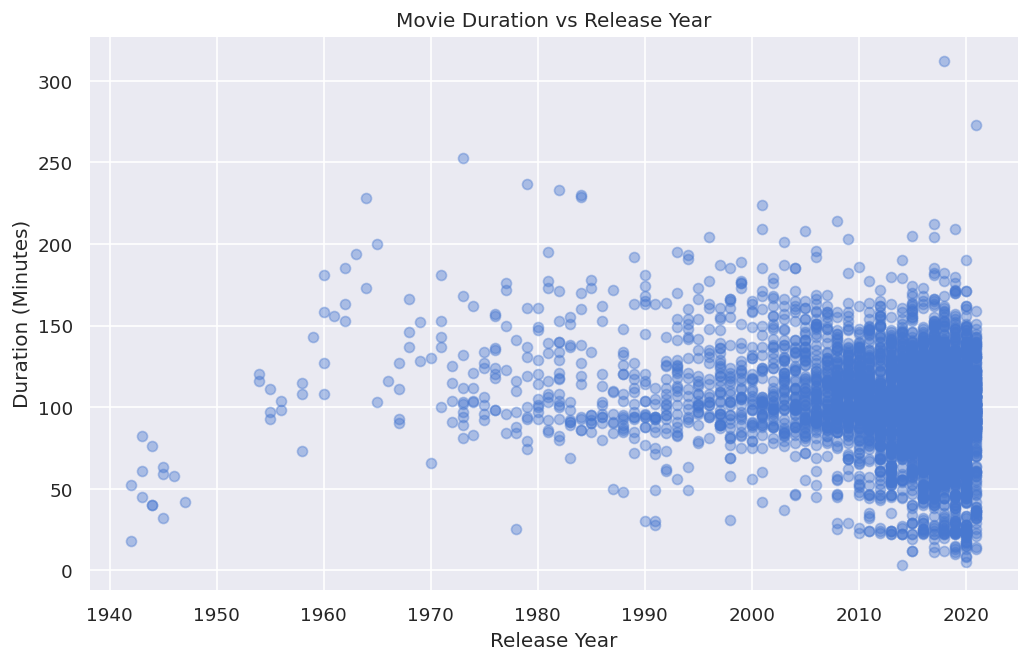

In [63]:
plt.figure(figsize=(10,6))
plt.scatter(
    movies['release_year'],
    movies['duration_mins'],
    alpha=0.4
)
plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.show()

---
## Step 5 — Insights Report

Here are 5 key findings from the analysis. Each one is backed by a chart above.

### Insight 1 — Netflix is predominantly a movie platform (Chart 1)
Around 70% of Netflix's catalog consists of movies, with TV Shows making up the remaining 30%. While TV shows might get more cultural attention and press, the sheer volume of movies on the platform is significantly higher. This suggests Netflix has invested more in acquiring or producing films than series, at least historically.

---

### Insight 2 — The United States dominates Netflix's content library (Chart 2)
The US produces more Netflix content than the next four countries combined. India comes in second, which reflects Netflix's strong push into the Indian market with original productions like Sacred Games and Delhi Crime. The UK, Canada, and France round out the top 5, indicating a heavy English-language and Western bias in the catalog.

---

### Insight 3 — Netflix's content addition peaked around 2018–2019, then slowed (Chart 3)
There was a sharp rise in content being added between 2015 and 2019, with both movies and TV shows growing rapidly. After 2019, growth slowed. This slowdown may be related to factors such as production disruptions during the COVID-19 period and changes in Netflix's content strategy. The drop visible in the most recent year might also simply be because that year isn't complete in the dataset.

---

### Insight 4 — Most Netflix movies are 80–110 minutes long (Chart 4)
The histogram shows a clear bell curve with the majority of movies clustering between 80 and 120 minutes. The median sits around 100 minutes. There are a few outliers — some very short (under 40 minutes, likely stand-up specials or short films) and some very long (over 150 minutes, likely epics or international cinema). For a streaming platform, keeping most content under 2 hours aligns well with viewer attention spans.

---

### Insight 5 — TV-MA is the most common rating, showing Netflix skews adult (Chart 5)
TV-MA (mature audiences) is by far the most common rating, followed by TV-14. This tells us Netflix's primary audience is adults and older teens. Family-friendly content (TV-G, TV-Y, G, PG) is a small fraction of the catalog. This is a deliberate positioning — Netflix differentiates itself from traditional broadcast TV by offering edgier, more mature content that wouldn't air on network channels.

---

## Most Surprising Finding

The most surprising finding for me was how much TV-MA content dominates Netflix's library. Before analyzing the data, I expected Netflix to have a more balanced mix of content for children, families, teenagers, and adults. Instead, TV-MA titles were by far the most common. This shows that Netflix focuses heavily on mature audiences and has built much of its catalog around content aimed at older viewers. It was interesting to see how different this is from traditional television, which usually offers a broader mix of age ratings.

---

## Conclusion

This analysis gave a solid overview of what Netflix's content library looks like. A few things stood out to me:
- The US-heavy bias is significant, but India's rise is clearly visible.
- Netflix's growth story is mostly a 2015–2019 story.
- The platform clearly targets adults, with TV-MA dominating the ratings landscape.

There's a lot more to explore — director networks, cast frequency, genre trends by country — but this covers the fundamentals well.

---
*Analysis by Siddharth | Netflix EDA Project *